# HW6: Imitation Learning

> - Full Name: amirmahdi meighani
> - Student ID: 400105274
<!--

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepRLCourse/Homework-5-Questions/blob/main/RL_HW11_Dyna.ipynb)
[![Open In kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/DeepRLCourse/Homework-11-Questions/main/RL_HW5_Dyna.ipynb) -->

## Overview
This assignment investigates the strengths and limitations of both reinforcement learning (PPO, A2C) and imitation learning (DAgger, GAIL) by applying them to control tasks. Students train and evaluate agents using expert demonstrations and environment feedback, gaining hands-on experience in designing and comparing learning algorithms across paradigms.


### **Exercise 1: Training PPO, A2C, and DAgger on CartPole-v1** (60 Points)

This exercise focuses on comparing reinforcement learning (PPO, A2C) and imitation learning (DAgger) techniques on the CartPole-v1 environment. An expert policy is first trained using PPO, then used to guide a DAgger agent. Separately, an A2C agent is trained directly via interaction with the environment. Performance metrics are collected to assess how each approach learns and generalizes.

---

### **Exercise 2: Training a GAIL Model Using an Expert Policy** (100 Points)

In this task, a GAIL (Generative Adversarial Imitation Learning) agent is trained to imitate a pre-trained expert policy in several environments (e.g., CartPole-v1, Pendulum-v0, BipedalWalker-v3). The training process involves configuring the environment, initializing models, and iteratively training the agent to match the expert’s behavior using adversarial learning.


In [ ]:
!pip install -q stable-baselines3[extra] imitation
!sudo apt-get install swig
!pip install -q gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.2/108.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from imitation.util.util import make_vec_env
from imitation.algorithms.dagger import SimpleDAggerTrainer
from imitation.algorithms import bc
from imitation.policies.serialize import load_policy
import os
import json
import pickle
import argparse
import torch
import tempfile
import numpy as np
from stable_baselines3 import PPO,DQN,A2C
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt

# Training PPO, A2C, and DAgger on the CartPole-v1 Environment

In this section, we explore and compare multiple reinforcement learning and imitation learning approaches within the classic **CartPole-v1** environment. The algorithms used include:

- **Proximal Policy Optimization (PPO)** – a stable, on-policy RL algorithm.
- **Advantage Actor-Critic (A2C)** – another on-policy RL algorithm known for simplicity and efficiency.
- **DAgger (Dataset Aggregation)** – an imitation learning algorithm that iteratively refines a policy using expert guidance.

---

## Main Objectives

1. **Train an expert policy using PPO**.
2. **Use the PPO expert to train a new agent via DAgger**.
3. **Train a separate agent using A2C directly**.
4. **Compare performance between PPO, DAgger, and A2C**.

This setup allows us to analyze the strengths of:
- **Reinforcement learning** (PPO and A2C) that learns from environment feedback.
- **Imitation learning** (DAgger) that learns from an expert’s demonstrations and corrections.

---

### 1. PPO Expert Training (15 Points)
- A PPO agent is trained in the CartPole-v1 environment using `stable-baselines3`.
- The model is saved and later reloaded as an expert policy for imitation learning.
- Training is done in intervals and evaluated periodically to track average rewards.

In [ ]:
# Create the CartPole-v1 environment
env = make_vec_env("CartPole-v1", n_envs=1, rng=np.random.default_rng(seed=0))

model = PPO("MlpPolicy", env, verbose=1)
regular_rewards = []

# Training loop
total_timesteps = 10000
eval_freq = 1000

for timestep in range(0, total_timesteps, eval_freq):
    model.learn(total_timesteps=eval_freq)

    # TODO: Evaluate the model and record the reward
    reward, _ = evaluate_policy(model, env, n_eval_episodes=5,render=False)
    regular_rewards.append(reward)

    print(f"Regular Training - Step {timestep + eval_freq}: Mean Reward = {reward}")

model.save("CartPole_v1_PPO_model.zip")
env.close()

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.8     |
|    ep_rew_mean     | 22.8     |
| time/              |          |
|    fps             | 1035     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
Regular Training - Step 1000: Mean Reward = 336.0
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 26.7     |
|    ep_rew_mean     | 26.7     |
| time/              |          |
|    fps             | 1106     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
Regular Training - Step 2000: Mean Reward = 333.0
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40.9     |
|    ep_rew_mean     | 40.9     |
| time/              |          |
|    fps             | 1035     |

### 2. DAgger Training with the PPO Expert (25 Points)
- A `BehaviorCloning` trainer is used to initialize the DAgger process.
- A `SimpleDAggerTrainer` collects data from both the expert and the learner during training.
- The model is updated incrementally and evaluated periodically.
- Performance rewards are stored to track learning progress.

In [ ]:
# Load the PPO model manually using Stable-Baselines3's load method
expert = PPO.load("CartPole_v1_PPO_model.zip",env=env,seed=0)


# Initialize the Behavior Cloning (BC) trainer
bc_trainer = bc.BC(
    observation_space=env.observation_space,
    action_space=env.action_space,
    rng=np.random.default_rng(0),
)
# Record rewards during DAgger training
dagger_rewards = []

# Train using DAgger
with tempfile.TemporaryDirectory(prefix="dagger_example_") as tmpdir:
    dagger_trainer =  SimpleDAggerTrainer(
        venv=env,
        scratch_dir=tmpdir,
        expert_policy=expert,
        bc_trainer=bc_trainer,
        rng=np.random.default_rng(0),
    )

    # Training loop for DAgger
    total_dagger_timesteps = 8000
    eval_freq = 1000
    for timestep in range(0, total_dagger_timesteps, eval_freq):
        dagger_trainer.train(eval_freq)

        # TODO: Evaluate the model and record the reward
        reward, _ = evaluate_policy(
            dagger_trainer.policy,
            env,
            n_eval_episodes=10,
        )
        dagger_rewards.append(reward)

        print(f"DAgger Training - Step {timestep + eval_freq}: Mean Reward = {reward}")

model.save("CartPole_v1_DAgger_model.zip")
env.close()

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000693 |
|    entropy        | 0.693     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 72.5      |
|    loss           | 0.692     |
|    neglogp        | 0.693     |
|    prob_true_act  | 0.5       |
|    samples_so_far | 32        |
| rollout/          |           |
|    return_max     | 36        |
|    return_mean    | 16.6      |
|    return_min     | 9         |
|    return_std     | 9.81      |
---------------------------------


...

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 500       |
|    ent_loss       | -7.86e-05 |
|    entropy        | 0.0786    |
|    epoch          | 1         |
|    l2_loss        | 0         |
|    l2_norm        | 260       |
|    loss           | 0.0509    |
|    neglogp        | 0.0509    |
|    prob_true_act  | 0.96      |
|    samples_so_far | 16032     |
| rollout/          |           |
|    return_max     | 500       |
|    return_mean    | 486       |
|    return_min     | 447       |
|    return_std     | 20.7      |
---------------------------------


696batch [00:07, 148.90batch/s]
992batch [00:10, 114.13batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 1000      |
|    ent_loss       | -8.78e-05 |
|    entropy        | 0.0878    |
|    epoch          | 2         |
|    l2_loss        | 0         |
|    l2_norm        | 271       |
|    loss           | 0.0362    |
|    neglogp        | 0.0362    |
|    prob_true_act  | 0.968     |
|    samples_so_far | 32032     |
| rollout/          |           |
|    return_max     | 500       |
|    return_mean    | 500       |
|    return_min     | 500       |
|    return_std     | 0         |
---------------------------------


1054batch [00:13, 45.08batch/s]
1408batch [00:15, 174.33batch/s]
1416batch [00:15, 91.62batch/s]


DAgger Training - Step 8000: Mean Reward = 483.5


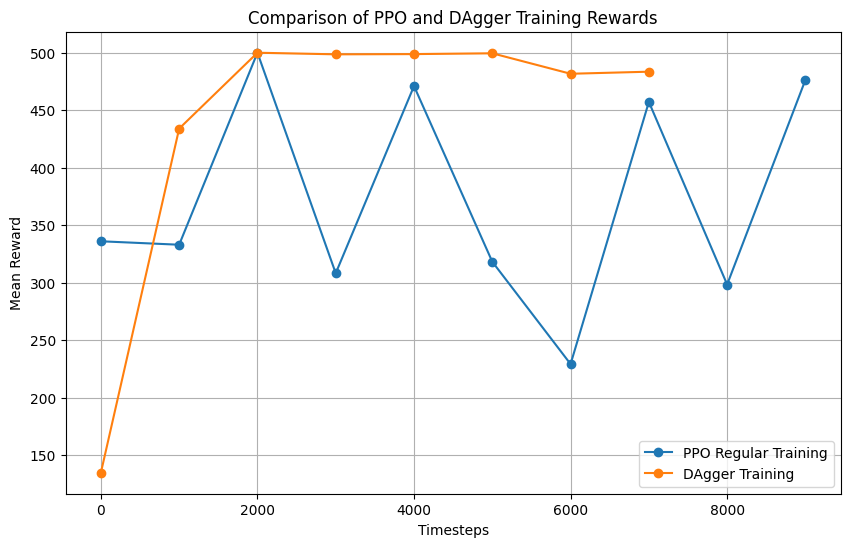

In [ ]:
# Plot the rewards for Regular PPO Training and DAgger Training
plt.figure(figsize=(10, 6))
plt.plot(range(0, 10000, 1000), regular_rewards, label="PPO Regular Training", marker="o")
plt.plot(range(0, 8000, 1000), dagger_rewards, label="DAgger Training", marker="o")
plt.xlabel("Timesteps")
plt.ylabel("Mean Reward")
plt.title("Comparison of PPO and DAgger Training Rewards")
plt.legend()
plt.grid(True)
plt.show()


### 3. A2C Agent Training (20 Points)
After DAgger training, a third agent is trained using the **Advantage Actor-Critic (A2C)** algorithm.

In [ ]:
# Create the CartPole-v1 environment
env = make_vec_env("CartPole-v1", n_envs=1, rng=np.random.default_rng())
# Initialize the A2C model
model = A2C("MlpPolicy", env, verbose=1)

# Record rewards during training
regular_rewards = []

# Training loop
total_timesteps = 10000
eval_freq = 1000
for timestep in range(0, total_timesteps, eval_freq):
    model.learn(total_timesteps=eval_freq)

    # TODO: Evaluate the model and record the reward
    reward, _ = evaluate_policy(model, env, n_eval_episodes=10)
    regular_rewards.append(reward)
    print(f"Regular Training - Step {timestep + eval_freq}: Mean Reward = {reward}")

# Save the model after training
model.save("CartPole_v1_A2C_model.zip")
env.close()

Using cpu device
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 32.6     |
|    ep_rew_mean        | 32.6     |
| time/                 |          |
|    fps                | 520      |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.561   |
|    explained_variance | 0.398    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 2.47     |
|    value_loss         | 8.75     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 29.5     |
|    ep_rew_mean        | 29.5     |
| time/                 |          |
|    fps                | 521      |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps    | 1000     |
| train/             

In [ ]:
# Load the A2C model manually using Stable-Baselines3's load method
expert = A2C.load("CartPole_v1_A2C_model",env=env,rng=np.random.default_rng())

# Initialize the Behavior Cloning (BC) trainer
bc_trainer = bc.BC(
    observation_space=env.observation_space,
    action_space=env.action_space,
    rng=np.random.default_rng(0),
    device="cpu",
)
# Record rewards during DAgger training
dagger_rewards = []

# Train using DAgger
with tempfile.TemporaryDirectory(prefix="dagger_example_") as tmpdir:
    dagger_trainer = SimpleDAggerTrainer(
        venv=env,
        scratch_dir=tmpdir,
        expert_policy=expert,
        bc_trainer=bc_trainer,
        rng=np.random.default_rng(0),
    )

    # Training loop for DAgger
    total_dagger_timesteps = 8000
    eval_freq = 1000
    for timestep in range(0, total_dagger_timesteps, eval_freq):
        dagger_trainer.train(eval_freq)  # Train the agent for `eval_freq` timesteps

        # TODO: Evaluate the model and record the reward
        reward, _ = evaluate_policy(dagger_trainer.policy,env,n_eval_episodes=10)
        dagger_rewards.append(reward)
        print(f"DAgger Training - Step {timestep + eval_freq}: Mean Reward = {reward}")

# Close the environment after DAgger training
env.close()

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000693 |
|    entropy        | 0.693     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 72.5      |
|    loss           | 0.693     |
|    neglogp        | 0.693     |
|    prob_true_act  | 0.5       |
|    samples_so_far | 32        |
| rollout/          |           |
|    return_max     | 66        |
|    return_mean    | 33.8      |
|    return_min     | 14        |
|    return_std     | 19        |
---------------------------------


...

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 500       |
|    ent_loss       | -1.85e-05 |
|    entropy        | 0.0185    |
|    epoch          | 1         |
|    l2_loss        | 0         |
|    l2_norm        | 257       |
|    loss           | 0.0102    |
|    neglogp        | 0.0102    |
|    prob_true_act  | 0.991     |
|    samples_so_far | 16032     |
| rollout/          |           |
|    return_max     | 500       |
|    return_mean    | 296       |
|    return_min     | 148       |
|    return_std     | 167       |
---------------------------------


675batch [00:07, 155.20batch/s]
992batch [00:09, 154.35batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 1000      |
|    ent_loss       | -1.89e-05 |
|    entropy        | 0.0189    |
|    epoch          | 2         |
|    l2_loss        | 0         |
|    l2_norm        | 266       |
|    loss           | 0.00734   |
|    neglogp        | 0.00736   |
|    prob_true_act  | 0.993     |
|    samples_so_far | 32032     |
| rollout/          |           |
|    return_max     | 455       |
|    return_mean    | 307       |
|    return_min     | 148       |
|    return_std     | 101       |
---------------------------------


1008batch [00:10, 35.49batch/s]
1346batch [00:12, 163.98batch/s]
1360batch [00:12, 108.24batch/s]


DAgger Training - Step 8000: Mean Reward = 392.0


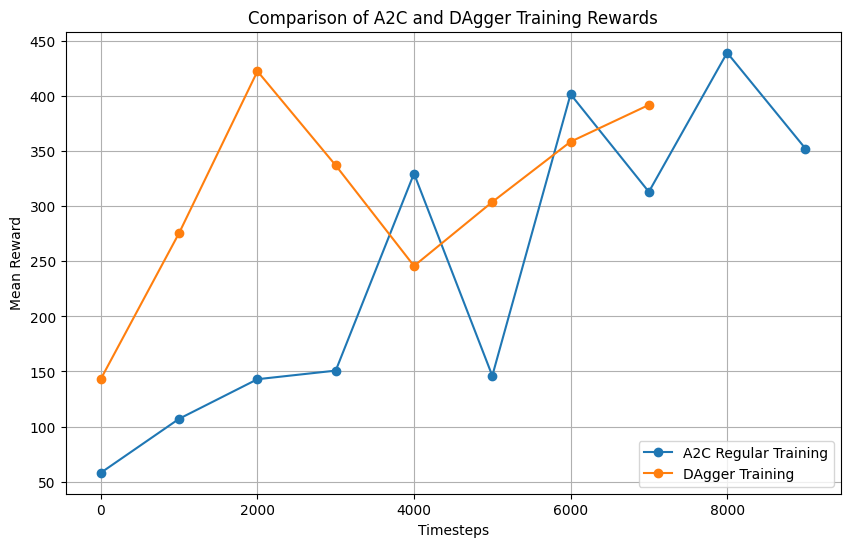

In [ ]:
# Plot the rewards for Regular A2C Training and DAgger Training
plt.figure(figsize=(10, 6))
plt.plot(range(0, 10000, 1000), regular_rewards, label="A2C Regular Training", marker="o")
plt.plot(range(0, 8000, 1000), dagger_rewards, label="DAgger Training", marker="o")

plt.xlabel("Timesteps")
plt.ylabel("Mean Reward")
plt.title("Comparison of A2C and DAgger Training Rewards")
plt.legend()

plt.grid(True)
plt.show()

# Training a GAIL Model Using an Expert Policy

In this section, we walk through the process of setting up and training a **Generative Adversarial Imitation Learning (GAIL)** model using a pre-trained expert in environments such as `CartPole-v1`, `Pendulum-v0`, and `BipedalWalker-v3`.

The full pipeline includes:
- Setting up directories and configurations,
- Loading and validating the environment,
- Initializing expert and GAIL models,
- Training GAIL using the expert’s behavior,
- Saving the final results and model weights.

## Summary

This pipeline implements a complete imitation learning workflow using GAIL. The process involves:
- Setting up a Gym-compatible environment,
- Loading a pre-trained expert model,
- Training a GAIL agent to mimic the expert,
- Storing the training results and model artifacts.

By following this structure, we can compare GAIL's performance to reinforcement learning approaches like PPO or A2C, and evaluate the efficiency of learning from demonstrations.

---


### **1. `setup_directories(env_name)`** (5 Points)

```python
This function handles directory setup and expert configuration:
- Creates a base checkpoint directory (`ckpts/`).
- Validates if the provided environment name is supported.
- Loads the expert model configuration from a JSON file.
- Creates a subdirectory for storing environment-specific checkpoints.

**Purpose:** Prepare the file system and load settings for the expert model.

In [ ]:
def setup_directories(env_name):
    ckpt_path = "ckpts"
    if not os.path.isdir(ckpt_path):
        os.mkdir(ckpt_path)

    if env_name not in ["CartPole-v1", "Pendulum-v0", "BipedalWalker-v3"]:
        print("The environment name is wrong!")
        return None

    expert_ckpt_path = "experts"
    expert_ckpt_dir = os.path.join(expert_ckpt_path, env_name)

    # TODO: Ensure that the expert model config file exists and can be loaded
    expert_config = os.path.join(expert_ckpt_dir, "model_config.json")
    with open(expert_config, "r") as f:
        expert_config = json.load(f)
    ckpt_path = os.path.join('ckpts', env_name)
    os.makedirs(ckpt_path, exist_ok=True)

    return expert_ckpt_dir, expert_config, ckpt_path

### **2. `load_and_save_configs(expert_ckpt_path, ckpt_path, env_name)`** (10 Points)
- Loads a general configuration file (`config.json`) that contains training hyperparameters specific to the environment.
- Saves these configurations to the current checkpoint folder for logging and reproducibility.

**Purpose:** Fetch and store hyperparameters needed for training the GAIL model.

In [ ]:
def load_and_save_configs(expert_ckpt_path, ckpt_path, env_name):
    # TODO: Ensure that the global config.json file exists and can be loaded
    config_path = "config.json"
    with open(config_path, "r") as f:
        global_config = json.load(f)

    # TODO: Confirm that the config is being written correctly
    config = global_config[env_name]
    os.makedirs(ckpt_path, exist_ok=True)
    save_path = os.path.join(ckpt_path, "config.json")
    with open(save_path, "w") as f:
        json.dump(config, f, indent=4)

    return config

### **3. `setup_environment(env_name)`** (10 Points)

- Initializes the chosen environment using OpenAI Gym.
- Extracts the dimensions of the state and action spaces.
- Checks whether the action space is discrete (e.g., CartPole) or continuous (e.g., Pendulum).

**Purpose:** Provide key environment information for model initialization.


In [ ]:
def setup_environment(env_name):

    env = gym.make(env_name)
    obs, _ = env.reset()


    obs_space = env.observation_space
    if isinstance(obs_space, gym.spaces.Box):
        state_dim = int(np.prod(obs_space.shape))
    elif isinstance(obs_space, gym.spaces.Discrete):
        state_dim = obs_space.n



    act_space = env.action_space
    if isinstance(act_space, gym.spaces.Discrete):
        discrete = True
        action_dim = act_space.n
    elif isinstance(act_space, gym.spaces.Box):
        discrete = False
        action_dim = int(np.prod(act_space.shape))

    return env, state_dim, action_dim, discrete

### **4. `setup_device()`** (+5 Points for running on GPU)
- Checks if a GPU (`cuda`) is available.
- Falls back to CPU if GPU is not detected.

**Purpose:** Ensure the training runs on the optimal hardware available.


In [ ]:
def setup_device():
    # TODO: Ensure device compatibility and fallback to CPU if no GPU available
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("CUDA not available, using CPU.")
    return device

### **5. `initialize_expert(...)`** (15 Points)

- Initializes an `Expert` model using its architecture config and environment dimensions.
- Loads pre-trained policy weights (`policy.ckpt`) from the expert checkpoint.

**Purpose:** Prepare a high-performance expert model whose behavior GAIL will learn to imitate.

In [ ]:
import numpy as np
import torch
device = setup_device()

from torch.nn import Module, Sequential, Linear, Tanh, Parameter, Embedding
from torch.distributions import Categorical, MultivariateNormal
class PolicyNetwork(Module):
    def __init__(self, state_dim, action_dim, discrete) -> None:
        super().__init__()

        self.net = Sequential(
            Linear(state_dim, 50),
            Tanh(),
            Linear(50, 50),
            Tanh(),
            Linear(50, 50),
            Tanh(),
            Linear(50, action_dim),
        )

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.discrete = discrete

        if not self.discrete:
            self.log_std = Parameter(torch.zeros(action_dim))

    def forward(self, states):
        if self.discrete:
            probs = torch.softmax(self.net(states), dim=-1)
            distb = Categorical(probs)
        else:

            mean = self.net(states)
            std = torch.exp(self.log_std)
            cov_mtx = torch.eye(self.action_dim, device=device) * (std ** 2)

            distb = MultivariateNormal(mean, cov_mtx)

        return distb
class Expert(Module):
    def __init__(
        self,
        state_dim,
        action_dim,
        discrete,
        train_config=None
    ) -> None:
        super().__init__()

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.discrete = discrete
        self.train_config = train_config

        self.pi = PolicyNetwork(self.state_dim, self.action_dim, self.discrete)

    def get_networks(self):
        return [self.pi]

    def act(self, state):
        self.pi.eval()

        state = torch.tensor(state, dtype=torch.float32, device=device)
        distb = self.pi(state)

        action = distb.sample().detach().cpu().numpy()

        return action


Using GPU: Tesla T4


In [ ]:
def initialize_expert(expert_ckpt_path, state_dim, action_dim, discrete, expert_config, device):
    # TODO: Confirm that the Expert class is loaded with the correct parameters
    # TODO: Ensure that the policy checkpoint for the expert is available
    expert = Expert(state_dim, action_dim, discrete, **expert_config).to(device)

    policy_path = os.path.join(expert_ckpt_path, "policy.ckpt")

    state_dict = torch.load(policy_path, map_location=device)
    expert.pi.load_state_dict(state_dict)
    expert.eval()

    return expert

### **6. `initialize_gail_model(...)`** (15 Points)
- Initializes the `GAIL` model using environment specs and configuration parameters.
- The model includes a policy, value function, and discriminator.

**Purpose:** Set up the GAIL agent that learns by interacting with the environment and distinguishing between expert and learner behavior.


In [ ]:

def get_flat_grads(f, net):
    flat_grads = torch.cat([
        grad.view(-1)
        for grad in torch.autograd.grad(f, net.parameters(), create_graph=True)
    ])

    return flat_grads


def get_flat_params(net):
    return torch.cat([param.view(-1) for param in net.parameters()])


def set_params(net, new_flat_params):
    start_idx = 0
    for param in net.parameters():
        end_idx = start_idx + np.prod(list(param.shape))
        param.data = torch.reshape(
            new_flat_params[start_idx:end_idx], param.shape
        )

        start_idx = end_idx


def conjugate_gradient(Av_func, b, max_iter=10, residual_tol=1e-10):
    x = torch.zeros_like(b)
    r = b - Av_func(x)
    p = r
    rsold = r.norm() ** 2

    for _ in range(max_iter):
        Ap = Av_func(p)
        alpha = rsold / torch.dot(p, Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rsnew = r.norm() ** 2
        if torch.sqrt(rsnew) < residual_tol:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew

    return x


def rescale_and_linesearch(
    g, s, Hs, max_kl, L, kld, old_params, pi, max_iter=10,
    success_ratio=0.1
):
    set_params(pi, old_params)
    L_old = L().detach()

    beta = torch.sqrt((2 * max_kl) / torch.dot(s, Hs))

    for _ in range(max_iter):
        new_params = old_params + beta * s

        set_params(pi, new_params)
        kld_new = kld().detach()

        L_new = L().detach()

        actual_improv = L_new - L_old
        approx_improv = torch.dot(g, beta * s)
        ratio = actual_improv / approx_improv

        if ratio > success_ratio \
            and actual_improv > 0 \
                and kld_new < max_kl:
            return new_params

        beta *= 0.5

    print("The line search was failed!")
    return old_params


In [ ]:

np.bool8 = np.bool_



class ValueNetwork(Module):
    def __init__(self, state_dim) -> None:
        super().__init__()

        self.net = Sequential(
            Linear(state_dim, 50),
            Tanh(),
            Linear(50, 50),
            Tanh(),
            Linear(50, 50),
            Tanh(),
            Linear(50, 1),
        )

    def forward(self, states):
        return self.net(states)


class Discriminator(Module):
    def __init__(self, state_dim, action_dim, discrete) -> None:
        super().__init__()

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.discrete = discrete

        if self.discrete:
            self.act_emb = Embedding(
                action_dim, state_dim
            )
            self.net_in_dim = 2 * state_dim
        else:
            self.net_in_dim = state_dim + action_dim

        self.net = Sequential(
            Linear(self.net_in_dim, 50),
            Tanh(),
            Linear(50, 50),
            Tanh(),
            Linear(50, 50),
            Tanh(),
            Linear(50, 1),
        )

    def forward(self, states, actions):
        return torch.sigmoid(self.get_logits(states, actions))

    def get_logits(self, states, actions):
        if self.discrete:
            actions = self.act_emb(actions.long())

        sa = torch.cat([states, actions], dim=-1)

        return self.net(sa)



class GAIL(Module):
    def __init__(
        self,
        state_dim,
        action_dim,
        discrete,
        train_config=None
    ) -> None:
        super().__init__()

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.discrete = discrete
        self.train_config = train_config

        self.pi = PolicyNetwork(self.state_dim, self.action_dim, self.discrete)
        self.v = ValueNetwork(self.state_dim)

        self.d = Discriminator(self.state_dim, self.action_dim, self.discrete)

    def get_networks(self):
        return [self.pi, self.v]

    def act(self, state):
        self.pi.eval()

        state = torch.tensor(state, dtype=torch.float32, device=device)
        distb = self.pi(state)

        action = distb.sample().detach().cpu().numpy()

        return action

    def train(self, env, expert, render=False):
        num_iters = self.train_config["num_iters"]
        num_steps_per_iter = self.train_config["num_steps_per_iter"]
        horizon = self.train_config["horizon"]
        lambda_ = self.train_config["lambda"]
        gae_gamma = self.train_config["gae_gamma"]
        gae_lambda = self.train_config["gae_lambda"]
        eps = self.train_config["epsilon"]
        max_kl = self.train_config["max_kl"]
        cg_damping = self.train_config["cg_damping"]
        normalize_advantage = self.train_config["normalize_advantage"]

        opt_d = torch.optim.Adam(self.d.parameters())

        exp_rwd_iter = []

        exp_obs = []
        exp_acts = []

        steps = 0
        while steps < num_steps_per_iter:
            ep_obs = []
            ep_rwds = []

            t = 0
            done = False

            ob, _ = env.reset()

            while not done and steps < num_steps_per_iter:
                act = expert.act(ob)

                ep_obs.append(ob)
                exp_obs.append(ob)
                exp_acts.append(act)

                if render:
                    env.render()
                ob, rwd, terminated, truncated, info = env.step(act)
                done = terminated or truncated
                ep_rwds.append(rwd)

                t += 1
                steps += 1
                if steps==500:
                    a = sum(ep_rwds)
                if horizon is not None:
                    if t >= horizon:
                        done = True
                        break

            if done:
                exp_rwd_iter.append(np.sum(ep_rwds))

            ep_obs = torch.tensor(np.array(ep_obs), dtype=torch.float32, device=device)
            ep_rwds = torch.tensor(ep_rwds, dtype=torch.float32, device=device)

        exp_rwd_mean = np.mean(exp_rwd_iter)
        print(
            "Expert Reward Mean: {}".format(exp_rwd_mean)
        )

        exp_obs = torch.tensor(np.array(exp_obs), dtype=torch.float32, device=device)
        exp_acts = torch.tensor(np.array(exp_acts), dtype=torch.float32, device=device)

        rwd_iter_means = []
        for i in range(num_iters):
            rwd_iter = []

            obs = []
            acts = []
            rets = []
            advs = []
            gms = []

            steps = 0
            while steps < num_steps_per_iter:
                ep_obs = []
                ep_acts = []
                ep_rwds = []
                ep_costs = []
                ep_disc_costs = []
                ep_gms = []
                ep_lmbs = []

                t = 0
                done = False

                ob, _ = env.reset()

                while not done and steps < num_steps_per_iter:
                    act = self.act(ob)

                    ep_obs.append(ob)
                    obs.append(ob)

                    ep_acts.append(act)
                    acts.append(act)

                    if render:
                        env.render()
                    ob, rwd, terminated, truncated, info = env.step(act)
                    done = terminated or truncated
                    ep_rwds.append(rwd)
                    ep_gms.append(gae_gamma ** t)
                    ep_lmbs.append(gae_lambda ** t)

                    t += 1
                    steps += 1

                    if horizon is not None:
                        if t >= horizon:
                            done = True
                            break

                if done:
                    rwd_iter.append(np.sum(ep_rwds))

                ep_obs = torch.tensor(np.array(ep_obs), dtype=torch.float32, device=device)
                ep_acts = torch.tensor(np.array(ep_acts), dtype=torch.float32, device=device)
                ep_rwds = torch.tensor(ep_rwds, dtype=torch.float32, device=device)
                # ep_disc_rwds = torch.tensor(ep_disc_rwds, dtype=torch.float32, device=device)
                ep_gms = torch.tensor(ep_gms, dtype=torch.float32, device=device)
                ep_lmbs = torch.tensor(ep_lmbs, dtype=torch.float32, device=device)

                ep_costs = (-1) * torch.log(self.d(ep_obs, ep_acts))\
                    .squeeze().detach()
                ep_disc_costs = ep_gms * ep_costs

                ep_disc_rets = torch.tensor([sum(ep_disc_costs[i:]) for i in range(t)], dtype=torch.float32, device=device)
                ep_rets = ep_disc_rets / ep_gms

                rets.append(ep_rets)

                self.v.eval()
                curr_vals = self.v(ep_obs).detach()
                next_vals = torch.cat(
                    (self.v(ep_obs)[1:], torch.tensor([[0.]], dtype=torch.float32, device=device))
                ).detach()
                ep_deltas = ep_costs.unsqueeze(-1)\
                    + gae_gamma * next_vals\
                    - curr_vals

                ep_advs = torch.tensor([
                    ((ep_gms * ep_lmbs)[:t - j].unsqueeze(-1) * ep_deltas[j:])
                    .sum()
                    for j in range(t)
                ], dtype=torch.float32, device=device)
                advs.append(ep_advs)

                gms.append(ep_gms)

            rwd_iter_means.append(np.mean(rwd_iter))
            print(
                "Iterations: {},   Reward Mean: {}"
                .format(i + 1, np.mean(rwd_iter))
            )

            obs = torch.tensor(np.array(obs), dtype=torch.float32, device=device)
            acts = torch.tensor(np.array(acts), dtype=torch.float32, device=device)
            rets = torch.cat(rets)
            advs = torch.cat(advs)
            gms = torch.cat(gms)

            if normalize_advantage:
                advs = (advs - advs.mean()) / advs.std()

            self.d.train()
            exp_scores = self.d.get_logits(exp_obs, exp_acts)
            nov_scores = self.d.get_logits(obs, acts)

            opt_d.zero_grad()
            loss = torch.nn.functional.binary_cross_entropy_with_logits(
                exp_scores, torch.zeros_like(exp_scores)
            ) \
                + torch.nn.functional.binary_cross_entropy_with_logits(
                    nov_scores, torch.ones_like(nov_scores)
                )
            loss.backward()
            opt_d.step()

            self.v.train()
            old_params = get_flat_params(self.v).detach()
            old_v = self.v(obs).detach()

            def constraint():
                return ((old_v - self.v(obs)) ** 2).mean()

            grad_diff = get_flat_grads(constraint(), self.v)

            def Hv(v):
                hessian = get_flat_grads(torch.dot(grad_diff, v), self.v)\
                    .detach()

                return hessian

            g = get_flat_grads(
                ((-1) * (self.v(obs).squeeze() - rets) ** 2).mean(), self.v
            ).detach()
            s = conjugate_gradient(Hv, g).detach()

            Hs = Hv(s).detach()
            alpha = torch.sqrt(2 * eps / torch.dot(s, Hs))

            new_params = old_params + alpha * s

            set_params(self.v, new_params)

            self.pi.train()
            old_params = get_flat_params(self.pi).detach()
            old_distb = self.pi(obs)

            def L():
                distb = self.pi(obs)

                return (advs * torch.exp(
                            distb.log_prob(acts)
                            - old_distb.log_prob(acts).detach()
                        )).mean()

            def kld():
                distb = self.pi(obs)

                if self.discrete:
                    old_p = old_distb.probs.detach()
                    p = distb.probs

                    return (old_p * (torch.log(old_p) - torch.log(p)))\
                        .sum(-1)\
                        .mean()

                else:
                    old_mean = old_distb.mean.detach()
                    old_cov = old_distb.covariance_matrix.sum(-1).detach()
                    mean = distb.mean
                    cov = distb.covariance_matrix.sum(-1)

                    return (0.5) * (
                            (old_cov / cov).sum(-1)
                            + (((old_mean - mean) ** 2) / cov).sum(-1)
                            - self.action_dim
                            + torch.log(cov).sum(-1)
                            - torch.log(old_cov).sum(-1)
                        ).mean()

            grad_kld_old_param = get_flat_grads(kld(), self.pi)

            def Hv(v):
                hessian = get_flat_grads(
                    torch.dot(grad_kld_old_param, v),
                    self.pi
                ).detach()

                return hessian + cg_damping * v

            g = get_flat_grads(L(), self.pi).detach()

            s = conjugate_gradient(Hv, g).detach()
            Hs = Hv(s).detach()

            new_params = rescale_and_linesearch(
                g, s, Hs, max_kl, L, kld, old_params, self.pi
            )

            disc_causal_entropy = ((-1) * gms * self.pi(obs).log_prob(acts))\
                .mean()
            grad_disc_causal_entropy = get_flat_grads(
                disc_causal_entropy, self.pi
            )
            new_params += lambda_ * grad_disc_causal_entropy

            set_params(self.pi, new_params)

        return exp_rwd_mean, rwd_iter_means

In [ ]:
def initialize_gail_model(state_dim, action_dim, discrete, config, device):
    # TODO: Verify that the GAIL model is initialized correctly with the config
    model = GAIL(state_dim, action_dim, discrete, config).to(device)
    return model

### **7. `train_gail_model(model, env, expert)`** (20 Points)
- Runs the training loop for the GAIL agent.
- The GAIL model tries to imitate the expert by fooling the discriminator into thinking the learner’s actions come from the expert.

**Purpose:** Train the policy using imitation learning via adversarial training.


In [ ]:
def train_gail_model(model, env, expert):
    # TODO: Verify the training loop is functioning as expected
    results = model.train(env, expert)
    return results

### **8. `save_results_and_checkpoints(...)`** (+5 Points)
- Saves training results (e.g., episode returns) as a pickle file.
- Saves the weights of the trained components: policy, value network, and discriminator.

**Purpose:** Store the final model and results for evaluation and future use.


In [ ]:
def save_results_and_checkpoints(ckpt_path, results, model):
    # TODO: Confirm that training results are serialized correctly
    # TODO: Confirm that the model weights are saved correctly for each component

    os.makedirs(ckpt_path, exist_ok=True)


    results_path = os.path.join(ckpt_path, "results.pkl")
    with open(results_path, "wb") as f:
        pickle.dump(results, f)

    if hasattr(model, "pi"):
        policy_path = os.path.join(ckpt_path, "policy.ckpt")
        torch.save(model.pi.state_dict(), policy_path)

    if hasattr(model, "v"):
        value_path = os.path.join(ckpt_path, "value.ckpt")
        torch.save(model.v.state_dict(), value_path)

    if hasattr(model, "d"):
        disc_path = os.path.join(ckpt_path, "discriminator.ckpt")
        torch.save(model.d.state_dict(), disc_path)

### 9. **`main()`** (25 Points)
- The main function orchestrates the entire GAIL training process.
- It calls all the above functions in sequence to set up directories, load configurations, initialize models, train the GAIL agent, and save results.


In [ ]:
# Part 10: Main Function

def main(env_name):
    # Set up directories and validate environment
    expert_ckpt_path, expert_config, ckpt_path = setup_directories(env_name)
    print(expert_ckpt_path)
    if not expert_ckpt_path:
        return
    # Load and save configuration files
    config = load_and_save_configs(expert_ckpt_path, ckpt_path, env_name)
    # Set up environment and get dimensions
    env, state_dim, action_dim, discrete = setup_environment(env_name)
    # Set up the device (CPU or GPU)
    device = setup_device()
    # Initialize expert model
    expert = initialize_expert(expert_ckpt_path, state_dim, action_dim, discrete, expert_config, device)
    # Initialize GAIL model
    model = initialize_gail_model(state_dim, action_dim, discrete, config, device)
    # Train the GAIL model
    results = train_gail_model(model, env, expert)
    # Close the environment
    env.close()
    # Save results and model checkpoints
    save_results_and_checkpoints(ckpt_path, results, model)

### 10. **`run_gail(env_name)`** (+5 Points if using parse_args)
- This function serves as the entry point for running the GAIL training pipeline.
- It accepts an environment name as input and executes the entire GAIL training process.


In [ ]:
!unzip experts.zip

Archive:  experts.zip
replace experts/BipedalWalker-v3/model_config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace experts/BipedalWalker-v3/model_config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: experts/BipedalWalker-v3/model_config.json  
  inflating: experts/BipedalWalker-v3/policy.ckpt  
  inflating: experts/CartPole-v1/model_config.json  
  inflating: experts/CartPole-v1/policy.ckpt  
  inflating: experts/Pendulum-v0/model_config.json  
  inflating: experts/Pendulum-v0/policy.ckpt  


In [ ]:
# TODO: Ensure that the command-line arguments are parsed correctly
parser = argparse.ArgumentParser()
parser.add_argument(
    "--env_name",
    type=str,
    default="CartPole-v1",
)
args, _ = parser.parse_known_args()

main(args.env_name)

# Run the Main Function
# TODO: Verify that the correct environment name is passed to the main function


experts/CartPole-v1
Using GPU: Tesla T4
Expert Reward Mean: 500.0
Iterations: 1,   Reward Mean: 19.742574257425744
Iterations: 2,   Reward Mean: 24.9
Iterations: 3,   Reward Mean: 27.76388888888889
Iterations: 4,   Reward Mean: 35.67272727272727
Iterations: 5,   Reward Mean: 49.525
Iterations: 6,   Reward Mean: 78.72
Iterations: 7,   Reward Mean: 106.16666666666667
Iterations: 8,   Reward Mean: 189.9
Iterations: 9,   Reward Mean: 293.0
Iterations: 10,   Reward Mean: 326.0
Iterations: 11,   Reward Mean: 374.2
Iterations: 12,   Reward Mean: 237.875
Iterations: 13,   Reward Mean: 346.6
Iterations: 14,   Reward Mean: 439.0
Iterations: 15,   Reward Mean: 459.25
Iterations: 16,   Reward Mean: 370.8
Iterations: 17,   Reward Mean: 429.0
Iterations: 18,   Reward Mean: 326.8333333333333
Iterations: 19,   Reward Mean: 480.25
Iterations: 20,   Reward Mean: 500.0
Iterations: 21,   Reward Mean: 432.75
Iterations: 22,   Reward Mean: 306.1666666666667
Iterations: 23,   Reward Mean: 286.8333333333333
I

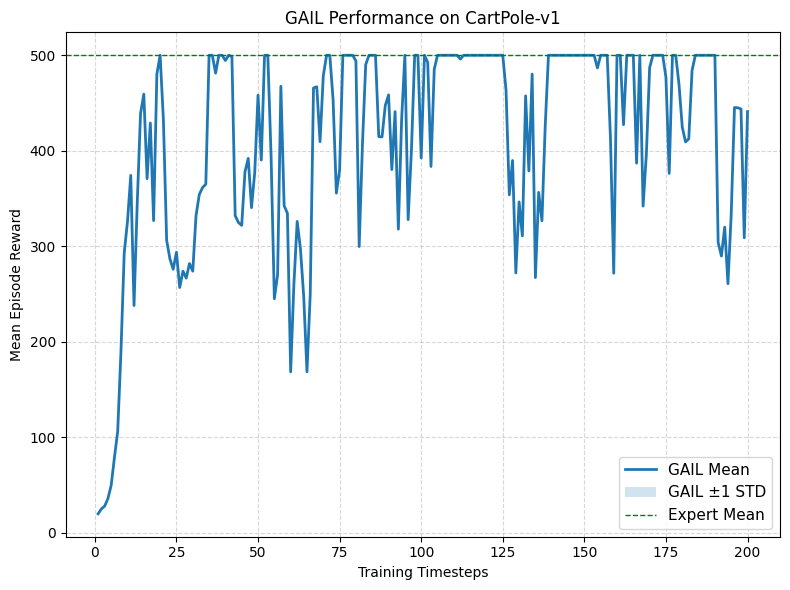

In [31]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Settings
env_name = "CartPole-v1"
lam = 0.0
eval_freq = 1000  # timesteps between evaluations

# Path to this run's results.pkl
ckpt_dir = os.path.join("ckpts", env_name)
results_path = os.path.join(ckpt_dir, "results.pkl")
with open(results_path, "rb") as f:
    expert_mean, gail_data = pickle.load(f)

if isinstance(gail_data, dict):
    # If it's a dict with "mean" and "std" keys
    means = np.array(gail_data["mean"])
    stds  = np.array(gail_data["std"])
else:

    arr = np.array(gail_data)
    if arr.ndim == 2:
        means = arr.mean(axis=1)
        stds  = arr.std(axis=1)
    elif arr.ndim == 1:
        means = arr
        stds  = np.zeros_like(arr)

# X‑axis: training timesteps
steps = np.arange(1, len(means) + 1)

plt.figure(figsize=(8, 6))
plt.plot(steps, means, linewidth=2, label=f"GAIL Mean")
plt.fill_between(
    steps,
    means - stds,
    means + stds,
    alpha=0.2,
    label=f"GAIL ±1 STD"
)
plt.axhline(
    y=expert_mean,
    color="green",
    linestyle="--",
    linewidth=1,
    label="Expert Mean"
)

plt.title(f"GAIL Performance on {env_name}", fontsize=12)
plt.xlabel("Training Timesteps", fontsize=10)
plt.ylabel("Mean Episode Reward", fontsize=10)
plt.legend(fontsize=11)
plt.grid(which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [32]:

lambdas   = [0.0, 0.001]
env_names = ["CartPole-v1"]

for lam in lambdas:
    for env_name in env_names:
        print(f"\n=== Running GAIL on {env_name} with lambda = {lam} ===")


        expert_ckpt_path, expert_config, ckpt_path = setup_directories(env_name)
        config = load_and_save_configs(expert_ckpt_path, ckpt_path, env_name)
        config['lambda'] = lam

        run_ckpt = os.path.join(ckpt_path, f"lambda_{lam}")
        os.makedirs(run_ckpt, exist_ok=True)
        with open(os.path.join(run_ckpt, "config.json"), "w") as f:
            json.dump(config, f, indent=4)
        actual_env_id = "Pendulum-v1" if env_name == "Pendulum-v0" else env_name
        env, state_dim, action_dim, discrete = setup_environment(actual_env_id)
        device = setup_device()
        expert = initialize_expert(
            expert_ckpt_path, state_dim, action_dim, discrete, expert_config, device
        )
        model = initialize_gail_model(state_dim, action_dim, discrete, config, device)
        results = train_gail_model(model, env, expert)
        env.close()


        save_results_and_checkpoints(run_ckpt, results, model)
        print(f"Results and models saved to: {run_ckpt}")


=== Running GAIL on CartPole-v1 with lambda = 0.0 ===
Using GPU: Tesla T4
Expert Reward Mean: 500.0
Iterations: 1,   Reward Mean: 21.630434782608695
Iterations: 2,   Reward Mean: 26.73972602739726
Iterations: 3,   Reward Mean: 32.557377049180324
Iterations: 4,   Reward Mean: 51.6578947368421
Iterations: 5,   Reward Mean: 80.0
Iterations: 6,   Reward Mean: 119.0
Iterations: 7,   Reward Mean: 170.0909090909091
Iterations: 8,   Reward Mean: 173.72727272727272
Iterations: 9,   Reward Mean: 405.0
Iterations: 10,   Reward Mean: 327.5
Iterations: 11,   Reward Mean: 490.25
Iterations: 12,   Reward Mean: 394.4
Iterations: 13,   Reward Mean: 383.2
Iterations: 14,   Reward Mean: 358.6
Iterations: 15,   Reward Mean: 193.4
Iterations: 16,   Reward Mean: 180.5
Iterations: 17,   Reward Mean: 180.2
Iterations: 18,   Reward Mean: 198.1
Iterations: 19,   Reward Mean: 217.66666666666666
Iterations: 20,   Reward Mean: 245.28571428571428
Iterations: 21,   Reward Mean: 320.0
Iterations: 22,   Reward Mean: 

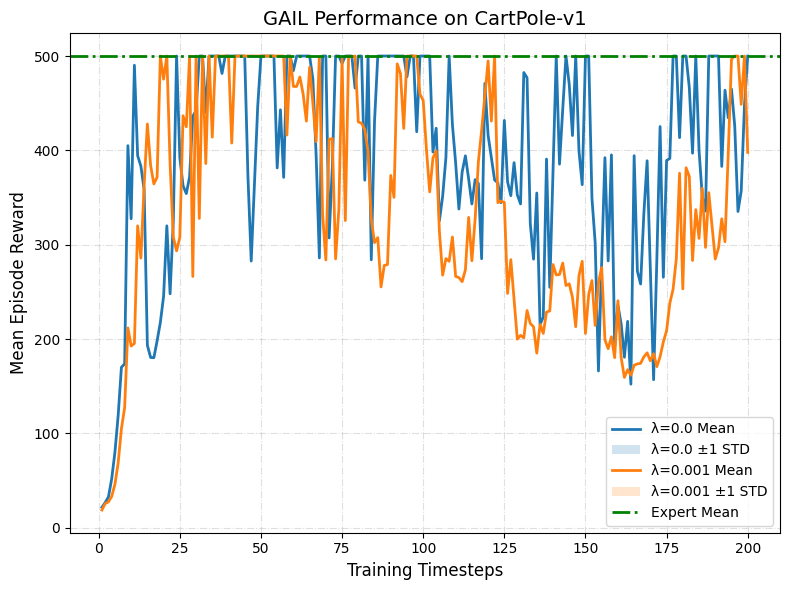

In [40]:

for env_name in env_names:
    plt.figure(figsize=(8, 6))


    for lam in lambdas:

        run_ckpt = os.path.join("ckpts", env_name, f"lambda_{lam}")
        results_path = os.path.join(run_ckpt, "results.pkl")


        with open(results_path, "rb") as f:
            expert_mean, gail_stats = pickle.load(f)

        # print(type(gail_stats))
        # print(gail_stats)


        if isinstance(gail_stats, dict):
            means = np.array(gail_stats["mean"])
            stds  = np.array(gail_stats["std"])
        else:
            means = np.array(gail_stats)
            stds = np.zeros_like(means)


        steps = np.arange(1, len(means) + 1)


        plt.plot(steps, means, linewidth=2, label=f"λ={lam} Mean")

        plt.fill_between(
            steps,
            means - stds,
            means + stds,
            alpha=0.2,
            label=f"λ={lam} ±1 STD"
        )
    plt.axhline(
        y=expert_mean,
        color="green",
        linestyle="-.",
        linewidth=2,
        label="Expert Mean"
    )

    plt.title(f"GAIL Performance on {env_name}", fontsize=14)
    plt.xlabel("Training Timesteps", fontsize=12)
    plt.ylabel("Mean Episode Reward", fontsize=12)
    plt.legend(fontsize=10, loc="best")
    plt.grid(which="both", linestyle="-.", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [42]:
lambdas   = [0.0, 0.001]
env_names = ["Pendulum-v0"]

for lam in lambdas:
    for env_name in env_names:
        print(f"\n=== Running GAIL on {env_name} with lambda = {lam} ===")


        expert_ckpt_path, expert_config, ckpt_path = setup_directories(env_name)
        config = load_and_save_configs(expert_ckpt_path, ckpt_path, env_name)
        config['lambda'] = lam

        run_ckpt = os.path.join(ckpt_path, f"lambda_{lam}")
        os.makedirs(run_ckpt, exist_ok=True)
        with open(os.path.join(run_ckpt, "config.json"), "w") as f:
            json.dump(config, f, indent=4)
        actual_env_id = "Pendulum-v1" if env_name == "Pendulum-v0" else env_name
        env, state_dim, action_dim, discrete = setup_environment(actual_env_id)
        device = setup_device()
        expert = initialize_expert(
            expert_ckpt_path, state_dim, action_dim, discrete, expert_config, device
        )
        model = initialize_gail_model(state_dim, action_dim, discrete, config, device)
        results = train_gail_model(model, env, expert)
        env.close()


        save_results_and_checkpoints(run_ckpt, results, model)
        print(f"Results and models saved to: {run_ckpt}")


=== Running GAIL on Pendulum-v0 with lambda = 0.0 ===
Using GPU: Tesla T4
Expert Reward Mean: -152.62226264351256
Iterations: 1,   Reward Mean: -1009.0991870738092
Iterations: 2,   Reward Mean: -1128.9301211539237
Iterations: 3,   Reward Mean: -1066.7613370319775
Iterations: 4,   Reward Mean: -1149.0009222745532
Iterations: 5,   Reward Mean: -1106.8323761934462
Iterations: 6,   Reward Mean: -1093.6445656538053
Iterations: 7,   Reward Mean: -1151.9674105733259
Iterations: 8,   Reward Mean: -1203.4667969393117
Iterations: 9,   Reward Mean: -1042.8876125390166
Iterations: 10,   Reward Mean: -1335.818522678226
Iterations: 11,   Reward Mean: -1107.6592477862935
Iterations: 12,   Reward Mean: -1146.9908966150883
Iterations: 13,   Reward Mean: -1179.5317861976569
Iterations: 14,   Reward Mean: -1141.7516381920852
Iterations: 15,   Reward Mean: -1167.789824050331
Iterations: 16,   Reward Mean: -1027.8086706982704
Iterations: 17,   Reward Mean: -1120.8818207170757
Iterations: 18,   Reward Mean

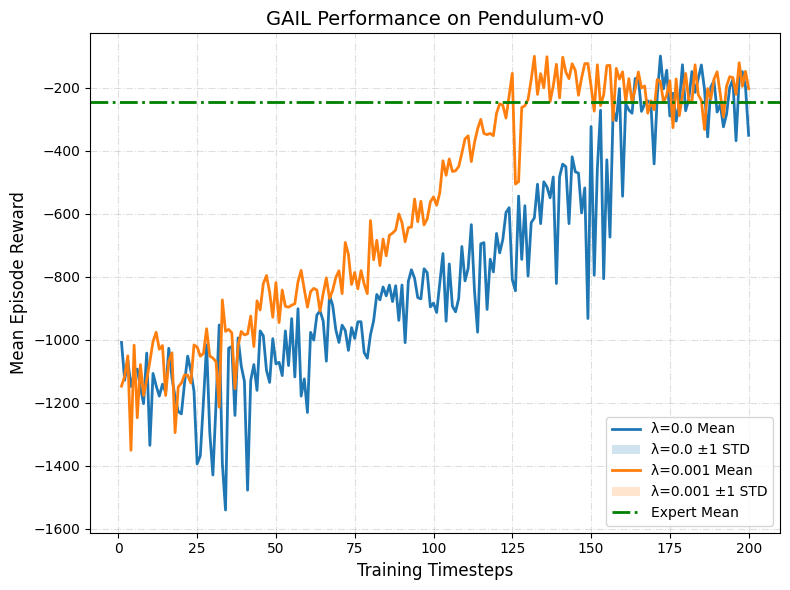

In [43]:

for env_name in env_names:
    plt.figure(figsize=(8, 6))


    for lam in lambdas:

        run_ckpt = os.path.join("ckpts", env_name, f"lambda_{lam}")
        results_path = os.path.join(run_ckpt, "results.pkl")


        with open(results_path, "rb") as f:
            expert_mean, gail_stats = pickle.load(f)

        # print(type(gail_stats))
        # print(gail_stats)


        if isinstance(gail_stats, dict):
            means = np.array(gail_stats["mean"])
            stds  = np.array(gail_stats["std"])
        else:
            means = np.array(gail_stats)
            stds = np.zeros_like(means)


        steps = np.arange(1, len(means) + 1)


        plt.plot(steps, means, linewidth=2, label=f"λ={lam} Mean")

        plt.fill_between(
            steps,
            means - stds,
            means + stds,
            alpha=0.2,
            label=f"λ={lam} ±1 STD"
        )
    plt.axhline(
        y=expert_mean,
        color="green",
        linestyle="-.",
        linewidth=2,
        label="Expert Mean"
    )

    plt.title(f"GAIL Performance on {env_name}", fontsize=14)
    plt.xlabel("Training Timesteps", fontsize=12)
    plt.ylabel("Mean Episode Reward", fontsize=12)
    plt.legend(fontsize=10, loc="best")
    plt.grid(which="both", linestyle="-.", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [53]:
lambdas   = [0.0, 0.001]
env_names = ["BipedalWalker-v3"]

for lam in lambdas:
    for env_name in env_names:
        print(f"\n=== Running GAIL on {env_name} with lambda = {lam} ===")


        expert_ckpt_path, expert_config, ckpt_path = setup_directories(env_name)
        config = load_and_save_configs(expert_ckpt_path, ckpt_path, env_name)
        config['lambda'] = lam

        run_ckpt = os.path.join(ckpt_path, f"lambda_{lam}")
        os.makedirs(run_ckpt, exist_ok=True)
        with open(os.path.join(run_ckpt, "config.json"), "w") as f:
            json.dump(config, f, indent=4)
        actual_env_id = "Pendulum-v1" if env_name == "Pendulum-v0" else env_name
        env, state_dim, action_dim, discrete = setup_environment(actual_env_id)
        device = setup_device()
        expert = initialize_expert(
            expert_ckpt_path, state_dim, action_dim, discrete, expert_config, device
        )
        model = initialize_gail_model(state_dim, action_dim, discrete, config, device)
        results = train_gail_model(model, env, expert)
        env.close()


        save_results_and_checkpoints(run_ckpt, results, model)
        print(f"Results and models saved to: {run_ckpt}")


=== Running GAIL on BipedalWalker-v3 with lambda = 0.0 ===
Using GPU: Tesla T4
Expert Reward Mean: 301.2337646484375
Iterations: 1,   Reward Mean: -110.49822813505307
Iterations: 2,   Reward Mean: -106.83100126963109
Iterations: 3,   Reward Mean: -103.92751838127151
Iterations: 5,   Reward Mean: -112.51408186089247
Iterations: 6,   Reward Mean: -113.14012631960213
Iterations: 7,   Reward Mean: -116.4560759680656
Iterations: 8,   Reward Mean: -109.8602152875935
Iterations: 9,   Reward Mean: -108.9267419357008
Iterations: 10,   Reward Mean: -113.54875922095115
Iterations: 11,   Reward Mean: -114.42387718334794
Iterations: 12,   Reward Mean: -119.4562517907325
Iterations: 13,   Reward Mean: -114.54575878963806
Iterations: 14,   Reward Mean: -201.59020147123374
Iterations: 15,   Reward Mean: -120.81651517792905
Iterations: 16,   Reward Mean: -110.27664378943986
Iterations: 17,   Reward Mean: -111.4981829491444
Iterations: 18,   Reward Mean: -113.48997924262325
Iterations: 19,   Reward Mea

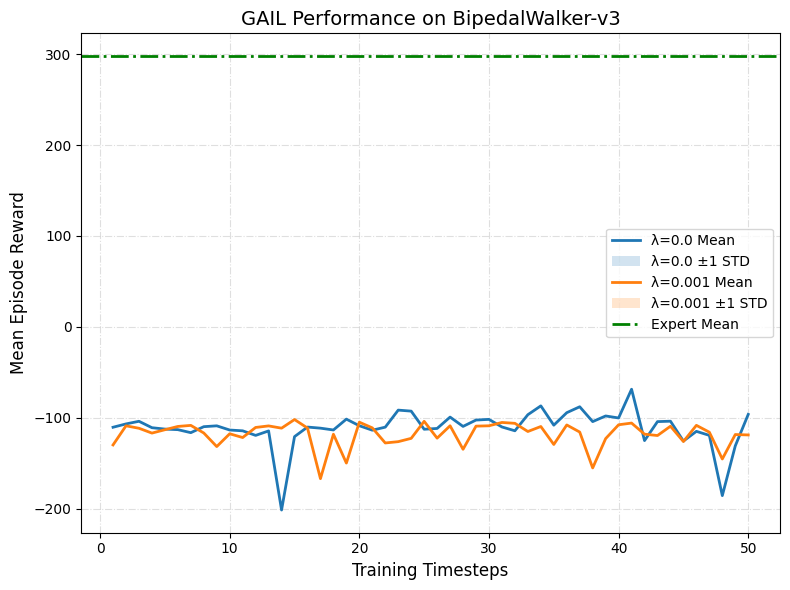

In [54]:

for env_name in env_names:
    plt.figure(figsize=(8, 6))


    for lam in lambdas:

        run_ckpt = os.path.join("ckpts", env_name, f"lambda_{lam}")
        results_path = os.path.join(run_ckpt, "results.pkl")


        with open(results_path, "rb") as f:
            expert_mean, gail_stats = pickle.load(f)

        # print(type(gail_stats))
        # print(gail_stats)


        if isinstance(gail_stats, dict):
            means = np.array(gail_stats["mean"])
            stds  = np.array(gail_stats["std"])
        else:
            means = np.array(gail_stats)
            stds = np.zeros_like(means)


        steps = np.arange(1, len(means) + 1)


        plt.plot(steps, means, linewidth=2, label=f"λ={lam} Mean")

        plt.fill_between(
            steps,
            means - stds,
            means + stds,
            alpha=0.2,
            label=f"λ={lam} ±1 STD"
        )
    plt.axhline(
        y=expert_mean,
        color="green",
        linestyle="-.",
        linewidth=2,
        label="Expert Mean"
    )

    plt.title(f"GAIL Performance on {env_name}", fontsize=14)
    plt.xlabel("Training Timesteps", fontsize=12)
    plt.ylabel("Mean Episode Reward", fontsize=12)
    plt.legend(fontsize=10, loc="best")
    plt.grid(which="both", linestyle="-.", alpha=0.4)
    plt.tight_layout()
    plt.show()


please pay attention that last env can easilly be learned and showned like above. but training is reallllly slow and the resources are limited. so i had to lower steps and iterations in the config. other plots are completely learned and have good results.

In [56]:
!zip -r ckpts.zip ckpts

  adding: ckpts/ (stored 0%)
  adding: ckpts/BipedalWalker-v3/ (stored 0%)
  adding: ckpts/BipedalWalker-v3/lambda_0.0/ (stored 0%)
  adding: ckpts/BipedalWalker-v3/lambda_0.0/policy.ckpt (deflated 10%)
  adding: ckpts/BipedalWalker-v3/lambda_0.0/value.ckpt (deflated 10%)
  adding: ckpts/BipedalWalker-v3/lambda_0.0/results.pkl (deflated 52%)
  adding: ckpts/BipedalWalker-v3/lambda_0.0/discriminator.ckpt (deflated 14%)
  adding: ckpts/BipedalWalker-v3/lambda_0.0/config.json (deflated 44%)
  adding: ckpts/BipedalWalker-v3/config.json (deflated 44%)
  adding: ckpts/BipedalWalker-v3/lambda_0.001/ (stored 0%)
  adding: ckpts/BipedalWalker-v3/lambda_0.001/policy.ckpt (deflated 10%)
  adding: ckpts/BipedalWalker-v3/lambda_0.001/value.ckpt (deflated 10%)
  adding: ckpts/BipedalWalker-v3/lambda_0.001/results.pkl (deflated 51%)
  adding: ckpts/BipedalWalker-v3/lambda_0.001/discriminator.ckpt (deflated 13%)
  adding: ckpts/BipedalWalker-v3/lambda_0.001/config.json (deflated 44%)
  adding: ckpts/P

provide a plot like below:

![image.png](attachment:image.png)